# AI-Powered Stock Decision System using Deep Learning and Real-Time News Sentiment Analysis


Stock : Saudi Aramco 2222

Data : Yahoo Finance (yfinance - auto downloaded historical data)

News : Google News RSS (Web Scraping)

Model : LSTM Neural Network (Time Series Forecasting)

NLP : FinBERT (Financial Sentiment Analysis)

Features:  Historical Price Data (Open, High, Low, Close, Volume) + News Sentiment Scores (Time-Weighted)


Output : BUY / SELL / HOLD + Confidence Score

...

In [ ]:
!pip install yfinance beautifulsoup4 requests lxml transformers xgboost scikit-learn --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings("ignore")

from datetime import date
from bs4 import BeautifulSoup
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

from transformers import pipeline
from urllib.parse import quote

In [ ]:
TICKER = "2222.SR"

data = yf.download(TICKER, start="2022-01-01", end=date.today().strftime("%Y-%m-%d"), auto_adjust=True)
data = data.reset_index()

data = data[['Date','Open','High','Low','Close','Volume']]
data.columns = ['Date','Open','High','Low','Price','Vol.']
data.dropna(inplace=True)

print("\n")
print("\n STOCK DATA SAMPLE:")
print(data.head(5).to_string(index=False))

print("\n")
print("\n LAST 5 ROWS:")
print(data.tail(5).to_string(index=False))

print("\n")
print("\n DATA INFO:")
print(data.describe())

[*********************100%***********************]  1 of 1 completed




 STOCK DATA SAMPLE:
      Date      Open      High       Low     Price    Vol.
2022-01-02 23.815969 23.815969 23.682734 23.682734 2644521
2022-01-03 23.649429 23.849283 23.649429 23.749355 3409916
2022-01-04 23.716045 23.782663 23.682736 23.716045 2423144
2022-01-05 23.682735 23.849281 23.682735 23.815971 2979819
2022-01-06 23.716046 23.749353 23.616117 23.616117 3839851



 LAST 5 ROWS:
      Date      Open      High       Low     Price     Vol.
2026-05-27 27.554003 27.554003 27.554003 27.554003        0
2026-05-28 27.554003 27.554003 27.554003 27.554003        0
2026-05-31 27.158962 27.277475 27.139210 27.198467 13488569
2026-06-01 27.178716 27.257724 26.961443 27.020700 27572123
2026-06-02 27.260000 27.480000 27.100000 27.379999 19366310



 DATA INFO:
                                Date         Open         High          Low  \
count                           1101  1101.000000  1101.000000  1101.000000   
mean   2024-03-19 07:58:41.525885440    26.042771    26.191347    25.8774

In [ ]:
sentiment_model = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def sentiment_score(text):
    try:
        r = sentiment_model(str(text))[0]
        if r["label"] == "positive":
            return r["score"]
        elif r["label"] == "negative":
            return -r["score"]
        return 0
    except:
        return 0

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def strip_tz(dt_index):
    dt_index = pd.to_datetime(dt_index)
    if dt_index.tz is not None:
        return dt_index.tz_convert(None)
    return dt_index

def strip_tz_scalar(dt):
    dt = pd.to_datetime(dt)
    if dt.tzinfo is not None:
        return dt.tz_convert(None).normalize()
    return dt.normalize()

def compute_impact_score(news_df, data):

    price_data = data.set_index('Date')[['Price', 'Vol.']].copy()
    price_data.index = strip_tz(price_data.index)

    price_data['Vol_MA10'] = price_data['Vol.'].rolling(10).mean()

    impact_scores = []

    for _, row in news_df.iterrows():
        news_date = strip_tz_scalar(row['Date'])

        future_dates = price_data.index[price_data.index > news_date]
        past_dates   = price_data.index[price_data.index <= news_date]

        if len(future_dates) == 0 or len(past_dates) == 0:
            impact_scores.append(0)
            continue

        next_day = future_dates[0]
        prev_day = past_dates[-1]

        price_before = price_data.loc[prev_day, 'Price']
        price_after  = price_data.loc[next_day, 'Price']

        # change price
        price_change_pct = (price_after - price_before) / (price_before + 1e-9)
        #the amaunt of the      in the AVG
        vol_after  = price_data.loc[next_day, 'Vol.']
        vol_ma     = price_data.loc[next_day, 'Vol_MA10']
        vol_ratio  = (vol_after / (vol_ma + 1e-9)) - 1
        vol_factor = np.clip(vol_ratio, -1, 1)
        #is the vector of news equls the price vector
        finbert_sign    = np.sign(row['Sentiment'])
        price_sign      = np.sign(price_change_pct)
        direction_match = 1 if finbert_sign == price_sign else -1

        # Impact Score
        raw_impact = (
            np.clip(price_change_pct * 10, -1, 1) * 0.50 +
            vol_factor                             * 0.30 +
            direction_match                        * 0.20
        )

        impact_scores.append(np.clip(raw_impact, -1, 1))

    news_df = news_df.copy()
    news_df['ImpactScore'] = impact_scores
    return news_df


print("✓ Impact Score function ready")

✓ Impact Score function ready


In [ ]:
def get_news():
    queries = [
        "Saudi Aramco stock",
        "Aramco 2222 سهم",
        "أرامكو السعودية سوق",
        "Aramco earnings results",
        "Aramco oil production",
        "Aramco dividend",
        "أرامكو أرباح توزيعات",
        "Saudi Aramco OPEC oil",
        "Aramco quarterly results",
        "Saudi oil price market",
        "أرامكو نتائج مالية",
        "Aramco 2222 تداول",
    ]

    all_articles = []

    for query in queries:
        url = f"https://news.google.com/rss/search?q={quote(query)}&hl=en-US&gl=US&ceid=US:en"
        try:
            resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
            soup = BeautifulSoup(resp.content, "xml")
            items = soup.find_all("item")

            for item in items[:50]:
                title = item.title.text if item.title else ""
                link  = item.link.text  if item.link  else ""
                pub   = item.pubDate.text if item.pubDate else ""
                try:
                    pub_date = pd.to_datetime(pub)
                except:
                    continue
                all_articles.append([pub_date, title, link])

        except Exception as e:
            print(f"  ⚠️ِ Erorr: {query} — {e}")
            continue

    news_df = pd.DataFrame(all_articles, columns=["Date", "Title", "Link"])
    news_df = news_df.drop_duplicates(subset=["Title"])
    news_df = news_df.sort_values("Date", ascending=False)

    print(f"   Total news after removing duplicates: {len(news_df)}")

    news_df["Sentiment"] = news_df["Title"].apply(sentiment_score)
    return news_df


news_df = get_news()

   Total news after removing duplicates: 311


In [ ]:
news_df = compute_impact_score(news_df, data)

print("\n IMPACT SCORE SAMPLE (Latest 5 News):")
latest_impact = news_df.sort_values('Date', ascending=False).head(5)
for _, row in latest_impact.iterrows():
    bar = '█' * int(abs(row['ImpactScore']) * 10)
    sign = '+' if row['ImpactScore'] >= 0 else '-'
    print(f"  [{sign}{bar:<10}] Impact={row['ImpactScore']:+.3f} | FinBERT={row['Sentiment']:+.3f}")
    print(f"   {row['Title'][:80]}")
    print()


 IMPACT SCORE SAMPLE (Latest 5 News):
  [+          ] Impact=+0.000 | FinBERT=+0.000
   Strait of Hormuz Oil Prices: Why Markets Remain Resilient - Discovery Alert

  [+          ] Impact=+0.000 | FinBERT=+0.000
   Iraq, UAE, Saudi Arabia All Set for Major Oil Output Surge in 2027 - Crude Oil P

  [+          ] Impact=+0.000 | FinBERT=+0.000
   Saudi Arabia Just Lost the Only OPEC Partner That Made Its Cuts Credible - house

  [+          ] Impact=+0.000 | FinBERT=+0.743
   Iran Joins United States, Saudi Arabia, Iraq, Kuwait, Qatar and United Arab Emir

  [+█         ] Impact=+0.121 | FinBERT=+0.000
   Saudi Arabia is considering lowering oil prices for Asia. - Inspenet



In [ ]:
daily_sentiment = []
daily_impact = []
daily_links = []

news_df["Date"] = pd.to_datetime(news_df["Date"]).dt.tz_localize(None).dt.normalize()
data["Date"]    = pd.to_datetime(data["Date"]).dt.tz_localize(None).dt.normalize()

for d in data["Date"]:

    mask = (news_df["Date"] >= d - pd.Timedelta(days=7)) & \
           (news_df["Date"] <= d + pd.Timedelta(days=1))
    past = news_df[mask]

    if len(past) > 0:

        days_diff = (d - past["Date"]).dt.days.clip(lower=0) + 1
        weights = np.exp(-days_diff / 10)

        sent = np.average(past["Sentiment"], weights=weights)
        impact = np.average(past["ImpactScore"], weights=weights)
        links = past["Link"].tail(3).tolist()

    else:
        sent = 0
        impact = 0
        links = []

    daily_sentiment.append(sent)
    daily_impact.append(impact)
    daily_links.append(links)

data["Sentiment"] = daily_sentiment
data["ImpactScore"] = daily_impact

print("\n LAST COMBINED DATA:")
print(data[['Date','Open','High','Low','Price','Vol.','Sentiment','ImpactScore']].tail(5).to_string(index=False))


 LAST COMBINED DATA:
      Date      Open      High       Low     Price     Vol.  Sentiment  ImpactScore
2026-05-27 27.554003 27.554003 27.554003 27.554003        0  -0.373244     0.142601
2026-05-28 27.554003 27.554003 27.554003 27.554003        0  -0.469540     0.138121
2026-05-31 27.158962 27.277475 27.139210 27.198467 13488569  -0.395625     0.177545
2026-06-01 27.178716 27.257724 26.961443 27.020700 27572123  -0.220401     0.124929
2026-06-02 27.260000 27.480000 27.100000 27.379999 19366310  -0.208302     0.121208


In [ ]:
features = ['Open','High','Low','Price','Vol.','Sentiment','ImpactScore']

SEQ   = 60
SPLIT = int((len(data) - SEQ) * 0.8)
train_size = SPLIT + SEQ

scaler = MinMaxScaler()
scaler.fit(data[features].iloc[:train_size])
scaled = scaler.transform(data[features])

X, y = [], []

for i in range(SEQ, len(scaled)):
    X.append(scaled[i-SEQ:i])
    y.append(scaled[i, 3])

X = np.array(X)
y = np.array(y)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Features     : {features}")
print(f"Input shape  : {X.shape}")

Features     : ['Open', 'High', 'Low', 'Price', 'Vol.', 'Sentiment', 'ImpactScore']
Input shape  : (1041, 60, 7)


In [ ]:
# This is a Models

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
results = {}  # save all models hare


# 1- LSTM
print("▶ Training LSTM...")
lstm_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32,
               validation_split=0.1, callbacks=[es], verbose=0)
results["LSTM"] = lstm_model
print("  ✓ LSTM done")


# 2- GRU
print("▶ Training GRU...")
gru_model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64),
    Dropout(0.3),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train, y_train, epochs=20, batch_size=32,
              validation_split=0.1, callbacks=[es], verbose=0)
results["GRU"] = gru_model
print("  ✓ GRU done")


# 3- Transformer
print("▶ Training Transformer...")
tf_input = Input(shape=(X.shape[1], X.shape[2]))
tf_x = MultiHeadAttention(num_heads=4, key_dim=32)(tf_input, tf_input)
tf_x = LayerNormalization()(tf_x)
tf_x = GlobalAveragePooling1D()(tf_x)
tf_x = Dense(64, activation="relu")(tf_x)
tf_x = Dropout(0.3)(tf_x)
tf_out = Dense(1)(tf_x)
transformer_model = Model(tf_input, tf_out)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.fit(X_train, y_train, epochs=20, batch_size=32,
                      validation_split=0.1, callbacks=[es], verbose=0)
results["Transformer"] = transformer_model
print("  ✓ Transformer done")


# 4- XGBoost
print("▶ Training XGBoost...")
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05,
                          max_depth=6, subsample=0.8,
                          colsample_bytree=0.8, random_state=42,
                          verbosity=0)
xgb_model.fit(X_train_2d, y_train)
results["XGBoost"] = xgb_model
print("  ✓ XGBoost done")


# 5- Random Forest
print("▶ Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_2d, y_train)
results["RandomForest"] = rf_model
print("  ✓ Random Forest done")


print("\n All 5 models trained successfully!")

▶ Training LSTM...
  ✓ LSTM done
▶ Training GRU...
  ✓ GRU done
▶ Training Transformer...
  ✓ Transformer done
▶ Training XGBoost...
  ✓ XGBoost done
▶ Training Random Forest...
  ✓ Random Forest done

 All 5 models trained successfully!


In [ ]:
# And this Prediction

price_scaler = MinMaxScaler()
price_scaler.fit(data[["Price"]].iloc[:train_size])

def inv(arr):
    # inverse transform helper
    return price_scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

real_inv = inv(y_test)

# LSTM
lstm_pred   = inv(lstm_model.predict(X_test, verbose=0).flatten())

# GRU
gru_pred    = inv(gru_model.predict(X_test, verbose=0).flatten())

# Transformer
trans_pred  = inv(transformer_model.predict(X_test, verbose=0).flatten())

# XGBoost
xgb_pred    = inv(xgb_model.predict(X_test_2d).flatten())

# Random Forest
rf_pred     = inv(rf_model.predict(X_test_2d).flatten())



all_preds = {
    "LSTM"        : lstm_pred,
    "GRU"         : gru_pred,
    "Transformer" : trans_pred,
    "XGBoost"     : xgb_pred,
    "RandomForest": rf_pred,
}

print("✓ All predictions ready")

✓ All predictions ready


In [ ]:
# Evaluation And Ensemble

metrics = {}

print(f"  {'Model':<15} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}")
print("  " + "─"*42)

for name, pred in all_preds.items():
    n = min(len(real_inv), len(pred))
    r = real_inv[:n]
    p = pred[:n]
    rmse = np.sqrt(mean_squared_error(r, p))
    mae  = mean_absolute_error(r, p)
    mape = np.mean(np.abs((r - p) / (r + 1e-9))) * 100
    metrics[name] = {"rmse": rmse, "mae": mae, "mape": mape, "pred": pred}
    print(f"  {name:<15} {rmse:>8.3f} {mae:>8.3f} {mape:>7.2f}%")

# Weighted Ensemble
rmse_vals   = np.array([metrics[m]["rmse"] for m in all_preds])
inv_rmse    = 1 / (rmse_vals + 1e-9)
weights_ens = inv_rmse / inv_rmse.sum()

min_len = min(len(p) for p in all_preds.values())
ensemble_pred = np.zeros(min_len)
for w, pred in zip(weights_ens, all_preds.values()):
    ensemble_pred += w * pred[:min_len]

real_ens = real_inv[:min_len]
ens_rmse = np.sqrt(mean_squared_error(real_ens, ensemble_pred))
ens_mae  = mean_absolute_error(real_ens, ensemble_pred)
ens_mape = np.mean(np.abs((real_ens - ensemble_pred) / (real_ens + 1e-9))) * 100
metrics["Ensemble"] = {"rmse": ens_rmse, "mae": ens_mae, "mape": ens_mape, "pred": ensemble_pred}

print("  " + "─"*42)
print(f"  {'Ensemble':<15} {ens_rmse:>8.3f} {ens_mae:>8.3f} {ens_mape:>7.2f}%  ← final")

# best model
best_model_name = min(metrics, key=lambda m: metrics[m]["rmse"])
print(f"\n  Best Model: {best_model_name} (RMSE={metrics[best_model_name]['rmse']:.3f})")


  Model               RMSE      MAE    MAPE%
  ──────────────────────────────────────────
  LSTM               0.617    0.524    2.10%
  GRU                0.386    0.309    1.24%
  Transformer        1.021    0.867    3.54%
  XGBoost            0.325    0.248    1.01%
  RandomForest       0.332    0.253    1.02%
  ──────────────────────────────────────────
  Ensemble           0.340    0.289    1.17%  ← final

  Best Model: XGBoost (RMSE=0.325)


In [ ]:
# Decision Engine

# Future Prediction
last_seq_dl  = scaled[-SEQ:].reshape(1, SEQ, len(features))
last_seq_ml  = scaled[-SEQ:].reshape(1, -1)

future_preds = {
    "LSTM"        : price_scaler.inverse_transform(lstm_model.predict(last_seq_dl, verbose=0))[0][0],
    "GRU"         : price_scaler.inverse_transform(gru_model.predict(last_seq_dl, verbose=0))[0][0],
    "Transformer" : price_scaler.inverse_transform(transformer_model.predict(last_seq_dl, verbose=0))[0][0],
    "XGBoost"     : float(inv(xgb_model.predict(last_seq_ml))),
    "RandomForest": float(inv(rf_model.predict(last_seq_ml))),
}

last_pred = (
    weights_ens[0] * future_preds["LSTM"]         +
    weights_ens[1] * future_preds["GRU"]           +
    weights_ens[2] * future_preds["Transformer"]   +
    weights_ens[3] * future_preds["XGBoost"]       +
    weights_ens[4] * future_preds["RandomForest"]
)

last_real = float(data["Price"].iloc[-1])

sent_mean   = np.mean(data["Sentiment"].tail(5))
impact_mean = np.mean(data["ImpactScore"].tail(5))

diff = last_pred - last_real
vol  = data["Price"].tail(30).std()

combined_signal = sent_mean * 0.4 + impact_mean * 0.6

if diff > vol * 0.5 and combined_signal > 0.2:
    decision = "STRONG BUY"
elif diff > vol * 0.3 and combined_signal > 0.15:
    decision = "BUY"
elif diff < -vol * 0.5 and combined_signal < -0.2:
    decision = "STRONG SELL"
elif diff < -vol * 0.3 and combined_signal < -0.15:
    decision = "SELL"
else:
    decision = "HOLD"

In [ ]:
# Confidence Score

# last sequence
all_future_preds = np.array(list(future_preds.values()))

pred_mean = np.mean(all_future_preds)
pred_std  = np.std(all_future_preds)

# coefficient of variation (std/mean)
cv = pred_std / (abs(pred_mean) + 1e-9)

model_agreement = max(0, 1 - cv * 5)  # يتراوح بين 0 و 1

sentiment_factor = min(1.0, abs(sent_mean)   / 0.5)
impact_factor    = min(1.0, abs(impact_mean) / 0.5)

lower_bound = pred_mean - 1.96 * pred_std
upper_bound = pred_mean + 1.96 * pred_std

confidence = (
    model_agreement  * 50 +
    sentiment_factor * 25 +
    impact_factor    * 25
) * 100

confidence = round(min(99, max(1, confidence)), 1)

print(f"\n PREDICTION DATA")
print(f"- Predicted Price    : {last_pred:.2f} SAR")
print(f"- Prediction Range   : {lower_bound:.2f} — {upper_bound:.2f} SAR")
print(f"- Model Std Dev      : ±{pred_std:.3f} SAR")
print(f"- Model Agreement    : {model_agreement*100:.1f}%")
print(f"- Confidence Score   : {confidence:.1f}%")


 PREDICTION DATA
- Predicted Price    : 27.26 SAR
- Prediction Range   : 26.90 — 27.51 SAR
- Model Std Dev      : ±0.154 SAR
- Model Agreement    : 97.2%
- Confidence Score   : 99.0%


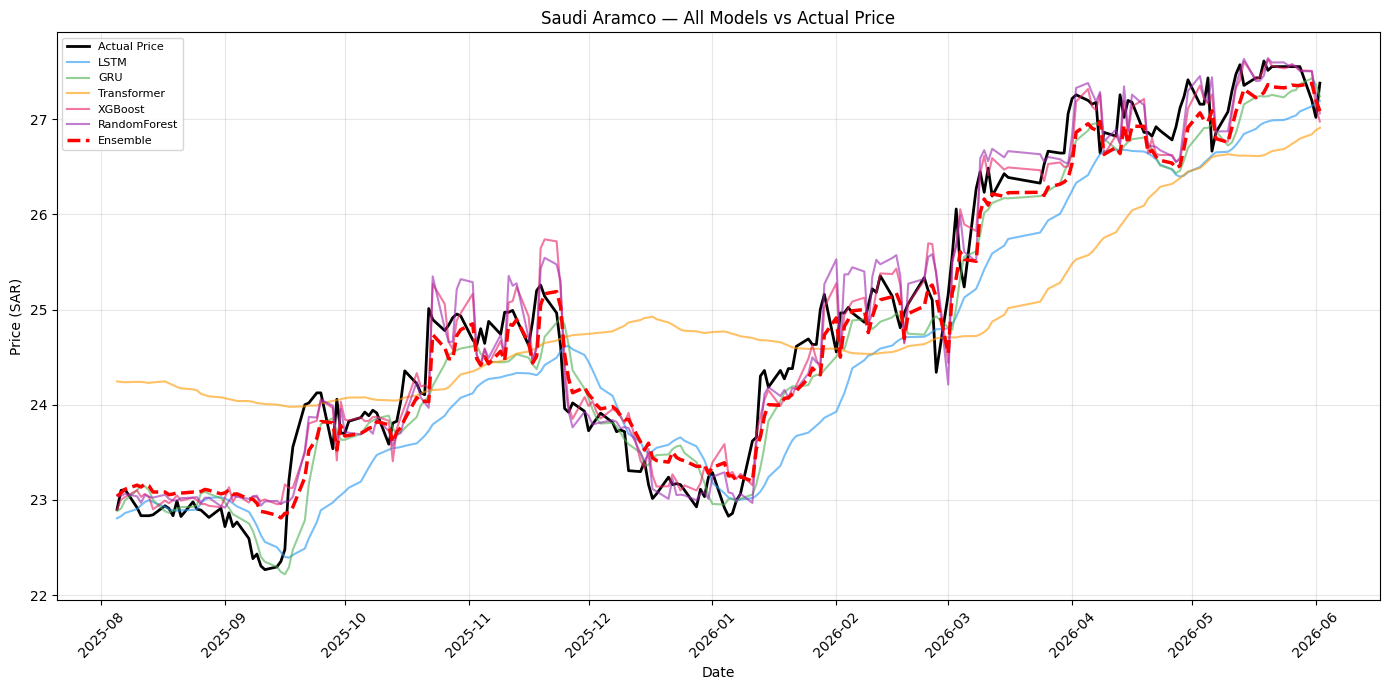

In [ ]:
dates = data["Date"].iloc[-min_len:].reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(dates, real_ens, label="Actual Price", color="black", linewidth=2)

colors = ["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0"]
for (name, pred), color in zip(all_preds.items(), colors):
    plt.plot(dates, pred[:min_len], label=name, alpha=0.6, color=color)

plt.plot(dates, ensemble_pred, label="Ensemble", color="red",
         linewidth=2.5, linestyle="--")

plt.title("Saudi Aramco — All Models vs Actual Price")
plt.ylabel("Price (SAR)")
plt.xlabel("Date")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

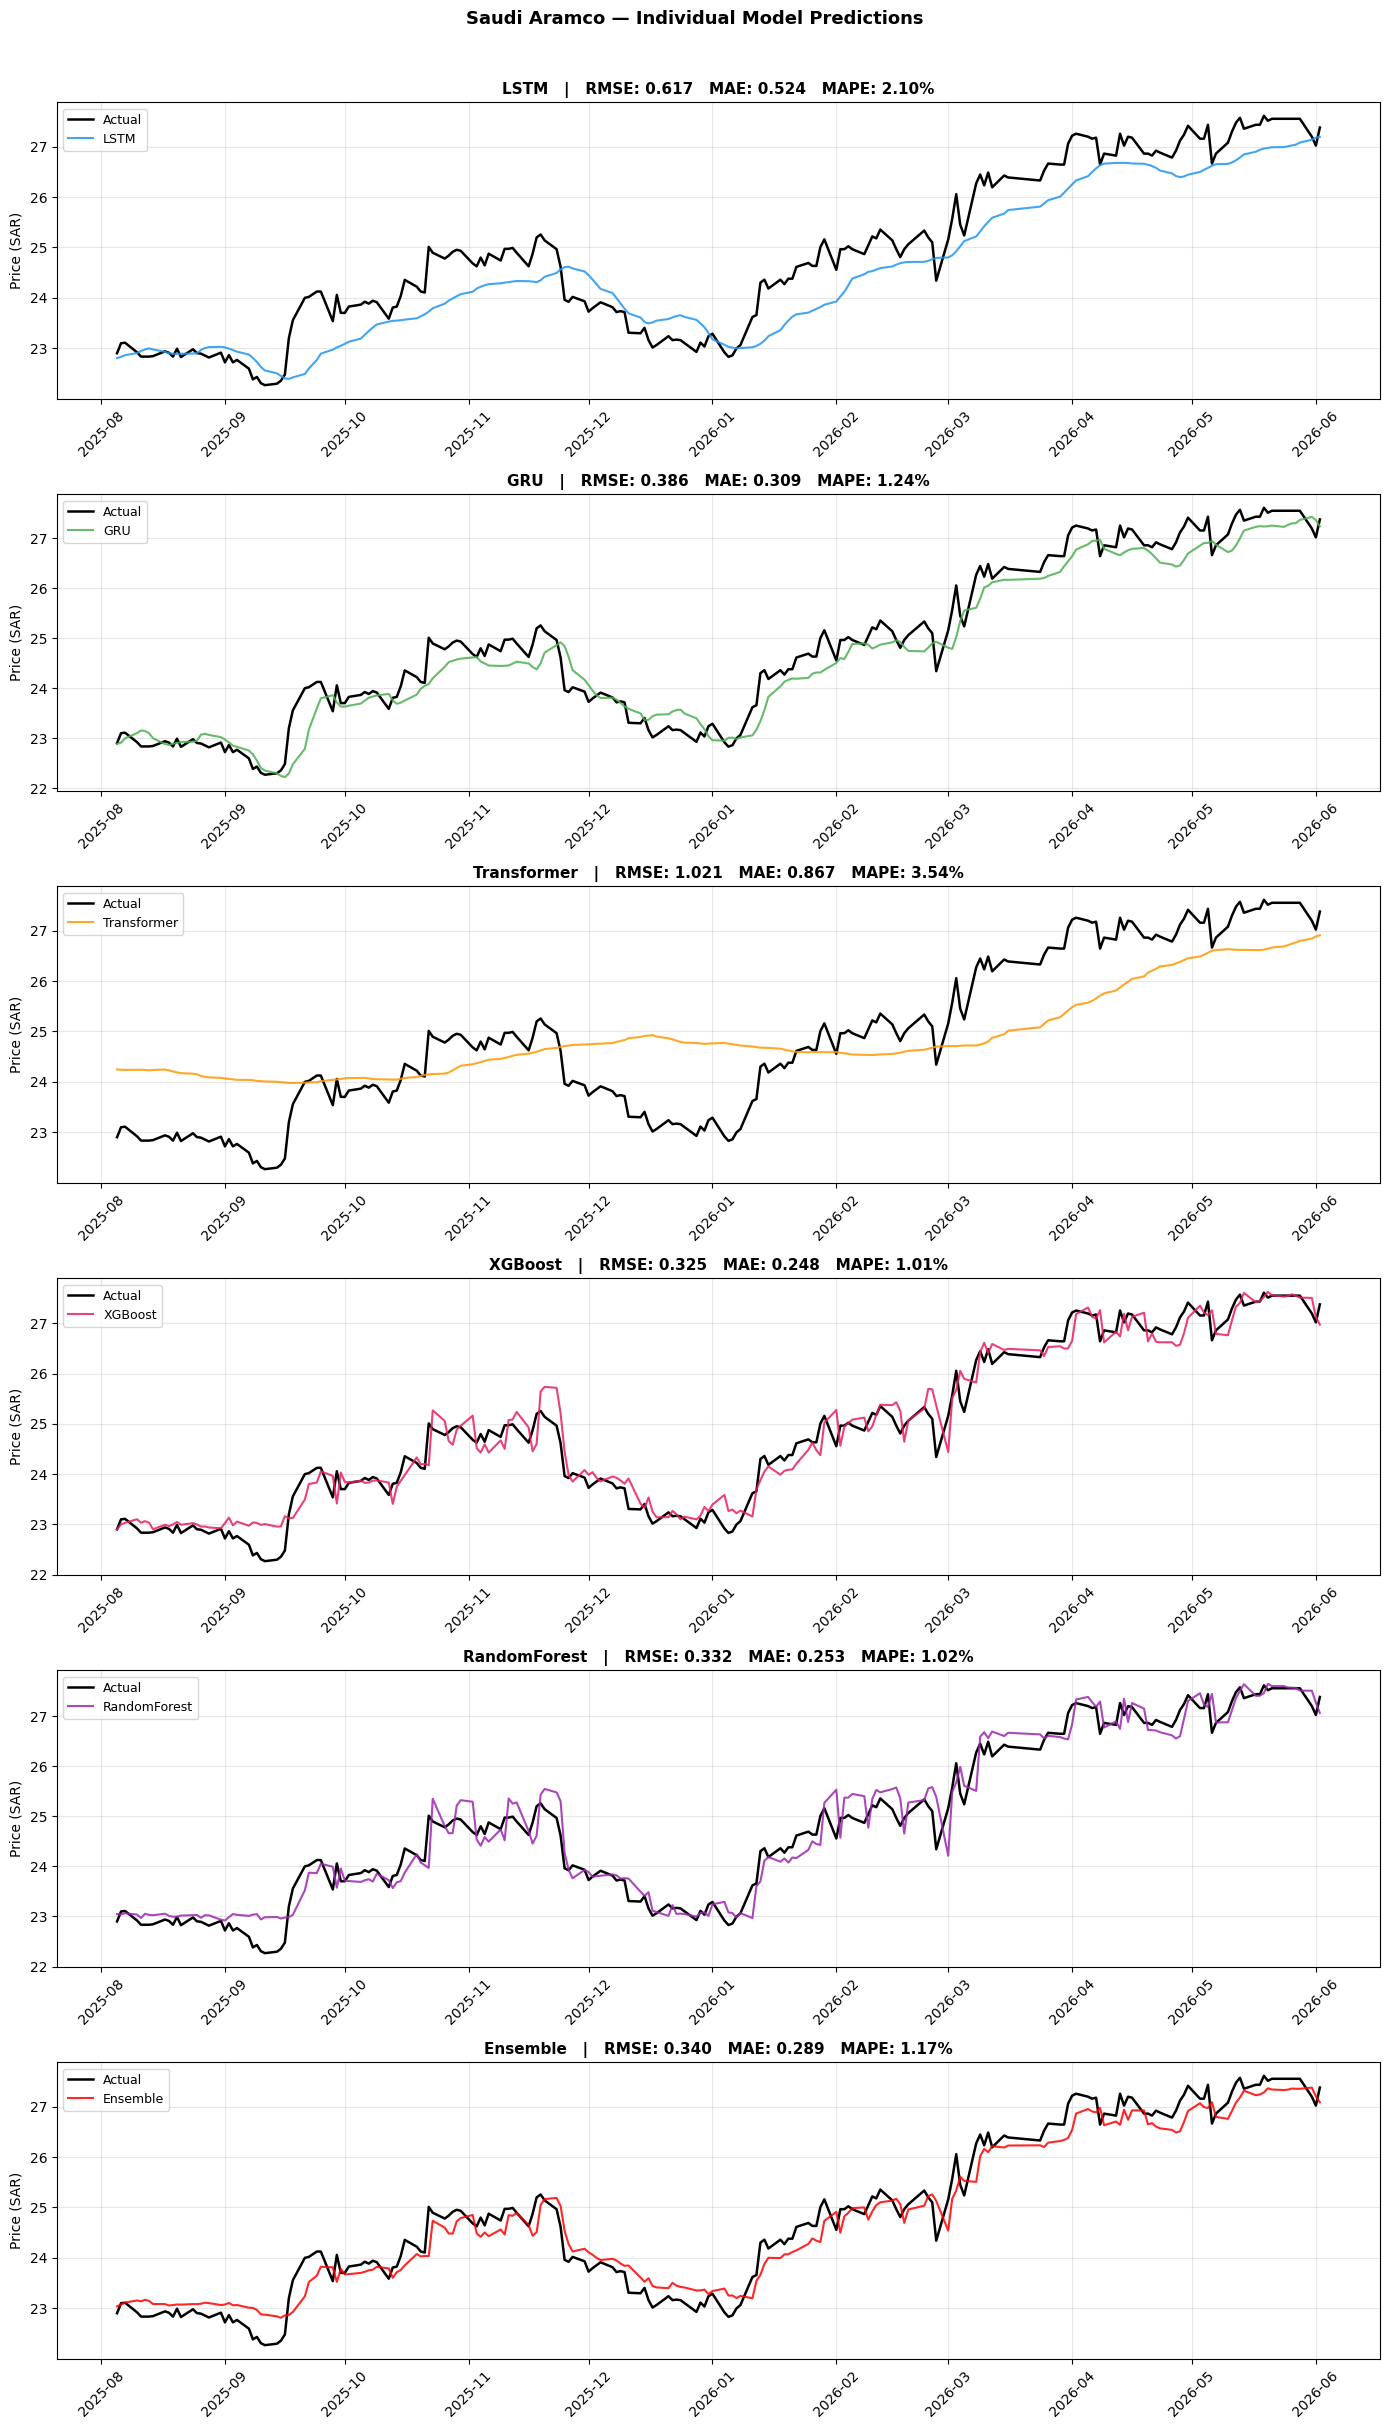

In [ ]:
dates = data["Date"].iloc[-min_len:].reset_index(drop=True)

colors = {
    "LSTM" : "#2196F3",
    "GRU" : "#4CAF50",
    "Transformer" : "#FF9800",
    "XGBoost" : "#E91E63",
    "RandomForest" : "#9C27B0",
    "Ensemble" : "red",
}

all_preds_with_ensemble = {**all_preds, "Ensemble": ensemble_pred}

fig, axes = plt.subplots(len(all_preds_with_ensemble), 1, figsize=(14, 4 * len(all_preds_with_ensemble)))

for ax, (name, pred) in zip(axes, all_preds_with_ensemble.items()):
    n = min(len(dates), len(pred))
    m = metrics[name]

    ax.plot(dates[:n], real_ens[:n], label="Actual",  color="black", linewidth=1.8)
    ax.plot(dates[:n], pred[:n],     label=name,      color=colors.get(name, "gray"), linewidth=1.5, alpha=0.85)

    ax.set_title(f"{name}   |   RMSE: {m['rmse']:.3f}   MAE: {m['mae']:.3f}   MAPE: {m['mape']:.2f}%",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (SAR)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Saudi Aramco — Individual Model Predictions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# REPORT

print(f"\n")
print("AI STOCK REPORT — Saudi ARAMCO 2222")


print("\n REAL DATA")
print(f"- Last Real Price : {last_real:.2f} SAR")
print(f"- Sentiment Avg   : {sent_mean:.3f}")
print(f"- Impact Score      : {impact_mean:+.3f}")
print(f"- Combined Signal   : {combined_signal:+.3f}")

print("\n PREDICTION DATA")
print(f"- Predicted Price  : {last_pred:.2f} SAR")
print(f"- Prediction Range : {lower_bound:.2f} — {upper_bound:.2f} SAR")
print(f"- Model Std Dev    : ±{pred_std:.3f} SAR")
print(f"- Model Agreement  : {model_agreement*100:.1f}%")
print(f"- Difference       : {diff:.2f} SAR")
print(f"- Confidence       : {confidence:.1f}%")

print("\n FINAL RECOMMENDATION")
print("\n")
print(f"   >>> {decision} <<<")

print("\n")



AI STOCK REPORT — Saudi ARAMCO 2222

 REAL DATA
- Last Real Price : 27.38 SAR
- Sentiment Avg   : -0.333
- Impact Score      : +0.141
- Combined Signal   : -0.049

 PREDICTION DATA
- Predicted Price  : 27.26 SAR
- Prediction Range : 26.90 — 27.51 SAR
- Model Std Dev    : ±0.154 SAR
- Model Agreement  : 97.2%
- Difference       : -0.12 SAR
- Confidence       : 99.0%

 FINAL RECOMMENDATION


   >>> HOLD <<<




In [ ]:
model_names = list(all_preds.keys())
print("\n ENSEMBLE WEIGHTS")
for name, w in zip(model_names, weights_ens):
    bar = "█" * int(w * 100)
    print(f"  {name:<15} {w*100:>5.1f}%  {bar}")


 ENSEMBLE WEIGHTS
  LSTM             14.4%  ██████████████
  GRU              23.0%  ██████████████████████
  Transformer       8.7%  ████████
  XGBoost          27.3%  ███████████████████████████
  RandomForest     26.7%  ██████████████████████████
